In [10]:
!pip install tensorflow pandas matplotlib seaborn scikit-learn pillow

In [11]:
import os

zip_path = "/val.zip"

print(os.path.exists(zip_path))

True


In [12]:
import zipfile
import os

zip_path = "/val.zip"
extract_path = "/content/plantvillage"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [13]:
import os

print(os.listdir("/content/plantvillage"))

['val']


In [14]:
dataset_path = "/content/plantvillage/val"

In [15]:
import os

classes = sorted(os.listdir(dataset_path))

print("Number of classes:", len(classes))

for i, class_name in enumerate(classes):
    print(i, class_name)

Number of classes: 38
0 Apple___Apple_scab
1 Apple___Black_rot
2 Apple___Cedar_apple_rust
3 Apple___healthy
4 Blueberry___healthy
5 Cherry_(including_sour)___Powdery_mildew
6 Cherry_(including_sour)___healthy
7 Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
8 Corn_(maize)___Common_rust_
9 Corn_(maize)___Northern_Leaf_Blight
10 Corn_(maize)___healthy
11 Grape___Black_rot
12 Grape___Esca_(Black_Measles)
13 Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
14 Grape___healthy
15 Orange___Haunglongbing_(Citrus_greening)
16 Peach___Bacterial_spot
17 Peach___healthy
18 Pepper,_bell___Bacterial_spot
19 Pepper,_bell___healthy
20 Potato___Early_blight
21 Potato___Late_blight
22 Potato___healthy
23 Raspberry___healthy
24 Soybean___healthy
25 Squash___Powdery_mildew
26 Strawberry___Leaf_scorch
27 Strawberry___healthy
28 Tomato___Bacterial_spot
29 Tomato___Early_blight
30 Tomato___Late_blight
31 Tomato___Leaf_Mold
32 Tomato___Septoria_leaf_spot
33 Tomato___Spider_mites Two-spotted_spider_mite
34 Tomat

In [16]:
total_images = 0

for class_name in classes:
    class_path = os.path.join(dataset_path, class_name)

    if os.path.isdir(class_path):
        count = len([
            f for f in os.listdir(class_path)
            if f.lower().endswith((".jpg", ".jpeg", ".png"))
        ])

        print(f"{class_name}: {count}")
        total_images += count

print("\nTotal images:", total_images)

Apple___Apple_scab: 126
Apple___Black_rot: 124
Apple___Cedar_apple_rust: 55
Apple___healthy: 329
Blueberry___healthy: 300
Cherry_(including_sour)___Powdery_mildew: 210
Cherry_(including_sour)___healthy: 170
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot: 102
Corn_(maize)___Common_rust_: 238
Corn_(maize)___Northern_Leaf_Blight: 197
Corn_(maize)___healthy: 232
Grape___Black_rot: 236
Grape___Esca_(Black_Measles): 276
Grape___Leaf_blight_(Isariopsis_Leaf_Spot): 215
Grape___healthy: 84
Orange___Haunglongbing_(Citrus_greening): 1101
Peach___Bacterial_spot: 459
Peach___healthy: 72
Pepper,_bell___Bacterial_spot: 199
Pepper,_bell___healthy: 295
Potato___Early_blight: 200
Potato___Late_blight: 200
Potato___healthy: 30
Raspberry___healthy: 74
Soybean___healthy: 1018
Squash___Powdery_mildew: 367
Strawberry___Leaf_scorch: 221
Strawberry___healthy: 91
Tomato___Bacterial_spot: 425
Tomato___Early_blight: 200
Tomato___Late_blight: 381
Tomato___Leaf_Mold: 190
Tomato___Septoria_leaf_spot: 354
Tomato_

In [17]:
import os
import shutil
import random

# Original dataset
source_dir = "/content/plantvillage/val"

# New dataset location
output_dir = "/content/plant_dataset"

# Split ratios
train_ratio = 0.70
validation_ratio = 0.15
test_ratio = 0.15

# Reproducibility
random.seed(42)

# Create train/validation/test folders
for split in ["train", "validation", "test"]:
    os.makedirs(os.path.join(output_dir, split), exist_ok=True)

# Process each class
for class_name in os.listdir(source_dir):

    class_source = os.path.join(source_dir, class_name)

    # Ignore files; only process directories
    if not os.path.isdir(class_source):
        continue

    # Get image files
    images = [
        f for f in os.listdir(class_source)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    # Shuffle images
    random.shuffle(images)

    # Calculate split points
    total = len(images)

    train_end = int(total * train_ratio)
    validation_end = train_end + int(total * validation_ratio)

    train_images = images[:train_end]
    validation_images = images[train_end:validation_end]
    test_images = images[validation_end:]

    # Create class folders
    for split in ["train", "validation", "test"]:
        os.makedirs(
            os.path.join(output_dir, split, class_name),
            exist_ok=True
        )

    # Copy images
    for image in train_images:
        shutil.copy2(
            os.path.join(class_source, image),
            os.path.join(output_dir, "train", class_name, image)
        )

    for image in validation_images:
        shutil.copy2(
            os.path.join(class_source, image),
            os.path.join(output_dir, "validation", class_name, image)
        )

    for image in test_images:
        shutil.copy2(
            os.path.join(class_source, image),
            os.path.join(output_dir, "test", class_name, image)
        )

print("Dataset splitting completed successfully!")

Dataset splitting completed successfully!


In [18]:
import os

for split in ["train", "validation", "test"]:

    split_path = os.path.join(
        "/content/plant_dataset",
        split
    )

    total = 0

    for class_name in os.listdir(split_path):

        class_path = os.path.join(
            split_path,
            class_name
        )

        if os.path.isdir(class_path):
            count = len([
                f for f in os.listdir(class_path)
                if f.lower().endswith((".jpg", ".jpeg", ".png"))
            ])

            total += count

    print(split, "images:", total)

train images: 7577
validation images: 1612
test images: 1660


In [19]:
train_classes = os.listdir("/content/plant_dataset/train")

print("Number of classes:", len(train_classes))

for class_name in sorted(train_classes):
    print(class_name)

Number of classes: 38
Apple___Apple_scab
Apple___Black_rot
Apple___Cedar_apple_rust
Apple___healthy
Blueberry___healthy
Cherry_(including_sour)___Powdery_mildew
Cherry_(including_sour)___healthy
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
Corn_(maize)___Common_rust_
Corn_(maize)___Northern_Leaf_Blight
Corn_(maize)___healthy
Grape___Black_rot
Grape___Esca_(Black_Measles)
Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
Grape___healthy
Orange___Haunglongbing_(Citrus_greening)
Peach___Bacterial_spot
Peach___healthy
Pepper,_bell___Bacterial_spot
Pepper,_bell___healthy
Potato___Early_blight
Potato___Late_blight
Potato___healthy
Raspberry___healthy
Soybean___healthy
Squash___Powdery_mildew
Strawberry___Leaf_scorch
Strawberry___healthy
Tomato___Bacterial_spot
Tomato___Early_blight
Tomato___Late_blight
Tomato___Leaf_Mold
Tomato___Septoria_leaf_spot
Tomato___Spider_mites Two-spotted_spider_mite
Tomato___Target_Spot
Tomato___Tomato_Yellow_Leaf_Curl_Virus
Tomato___Tomato_mosaic_virus
Tomato___he

In [20]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Image dimensions
IMG_SIZE = (128, 128)

# Number of images processed at once
BATCH_SIZE = 32

# Dataset paths
train_path = "/content/plant_dataset/train"
validation_path = "/content/plant_dataset/validation"
test_path = "/content/plant_dataset/test"

# Training data augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True
)

# Validation and test data: only normalization
validation_datagen = ImageDataGenerator(
    rescale=1./255
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

# Load training images
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

# Load validation images
validation_generator = validation_datagen.flow_from_directory(
    validation_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

# Load test images
test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

print("\nNumber of classes:", train_generator.num_classes)

Found 7577 images belonging to 38 classes.
Found 1612 images belonging to 38 classes.
Found 1660 images belonging to 38 classes.

Number of classes: 38


In [21]:
print("Training images:", train_generator.samples)
print("Validation images:", validation_generator.samples)
print("Test images:", test_generator.samples)
print("Number of classes:", train_generator.num_classes)

Training images: 7577
Validation images: 1612
Test images: 1660
Number of classes: 38


In [22]:
class_indices = train_generator.class_indices

for class_name, index in class_indices.items():
    print(index, "->", class_name)

0 -> Apple___Apple_scab
1 -> Apple___Black_rot
2 -> Apple___Cedar_apple_rust
3 -> Apple___healthy
4 -> Blueberry___healthy
5 -> Cherry_(including_sour)___Powdery_mildew
6 -> Cherry_(including_sour)___healthy
7 -> Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
8 -> Corn_(maize)___Common_rust_
9 -> Corn_(maize)___Northern_Leaf_Blight
10 -> Corn_(maize)___healthy
11 -> Grape___Black_rot
12 -> Grape___Esca_(Black_Measles)
13 -> Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
14 -> Grape___healthy
15 -> Orange___Haunglongbing_(Citrus_greening)
16 -> Peach___Bacterial_spot
17 -> Peach___healthy
18 -> Pepper,_bell___Bacterial_spot
19 -> Pepper,_bell___healthy
20 -> Potato___Early_blight
21 -> Potato___Late_blight
22 -> Potato___healthy
23 -> Raspberry___healthy
24 -> Soybean___healthy
25 -> Squash___Powdery_mildew
26 -> Strawberry___Leaf_scorch
27 -> Strawberry___healthy
28 -> Tomato___Bacterial_spot
29 -> Tomato___Early_blight
30 -> Tomato___Late_blight
31 -> Tomato___Leaf_Mold
32 -> Tomato__

In [23]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

# Create CNN model
model = Sequential([

    # Convolutional Layer 1
    Conv2D(
        32,
        (3, 3),
        activation="relu",
        input_shape=(128, 128, 3)
    ),

    # Pooling Layer 1
    MaxPooling2D(pool_size=(2, 2)),

    # Convolutional Layer 2
    Conv2D(
        64,
        (3, 3),
        activation="relu"
    ),

    # Pooling Layer 2
    MaxPooling2D(pool_size=(2, 2)),

    # Convolutional Layer 3
    Conv2D(
        128,
        (3, 3),
        activation="relu"
    ),

    # Pooling Layer 3
    MaxPooling2D(pool_size=(2, 2)),

    # Convert feature maps to 1D
    Flatten(),

    # Fully connected layer
    Dense(
        128,
        activation="relu"
    ),

    # Dropout to reduce overfitting
    Dropout(0.5),

    # Output layer
    Dense(
        38,
        activation="softmax"
    )
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │         4,902 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,309,542 (12.62 MB)

 Trainable params: 3,309,542 (12.62 MB)

 Non-trainable params: 0 (0.00 B)

In [24]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully!")

Model compiled successfully!


In [25]:
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=validation_generator
)

Epoch 1/10
237/237 ━━━━━━━━━━━━━━━━━━━━ 55s 207ms/step - accuracy: 0.2266 - loss: 2.9936 - val_accuracy: 0.3778 - val_loss: 2.3353
Epoch 2/10
237/237 ━━━━━━━━━━━━━━━━━━━━ 43s 179ms/step - accuracy: 0.3768 - loss: 2.3026 - val_accuracy: 0.5012 - val_loss: 1.8153
Epoch 3/10
237/237 ━━━━━━━━━━━━━━━━━━━━ 43s 180ms/step - accuracy: 0.4540 - loss: 1.9644 - val_accuracy: 0.5354 - val_loss: 1.6402
Epoch 4/10
237/237 ━━━━━━━━━━━━━━━━━━━━ 42s 175ms/step - accuracy: 0.5147 - loss: 1.7125 - val_accuracy: 0.6507 - val_loss: 1.1577
Epoch 5/10
237/237 ━━━━━━━━━━━━━━━━━━━━ 40s 167ms/step - accuracy: 0.5449 - loss: 1.5649 - val_accuracy: 0.6613 - val_loss: 1.1064
Epoch 6/10
237/237 ━━━━━━━━━━━━━━━━━━━━ 40s 168ms/step - accuracy: 0.5890 - loss: 1.4033 - val_accuracy: 0.6774 - val_loss: 1.0661
Epoch 7/10
237/237 ━━━━━━━━━━━━━━━━━━━━ 39s 164ms/step - accuracy: 0.6064 - loss: 1.3427 - val_accuracy: 0.6973 - val_loss: 0.9848
Epoch 8/10
237/237 ━━━━━━━━━━━━━━━━━━━━ 39s 166ms/step - accuracy: 0.6276 - loss: 1

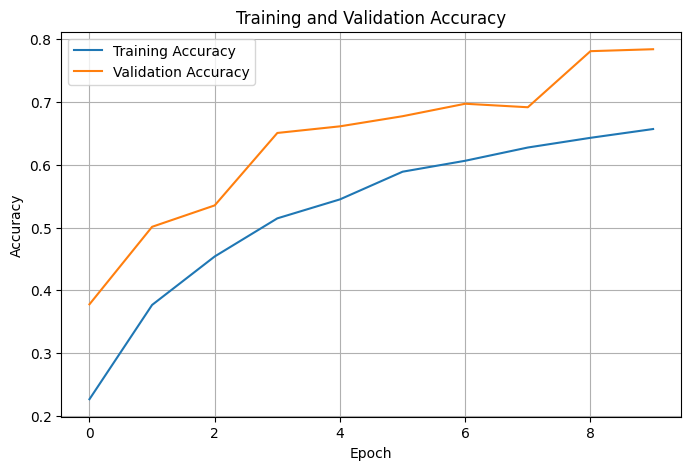

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")

plt.legend()
plt.grid(True)

plt.show()

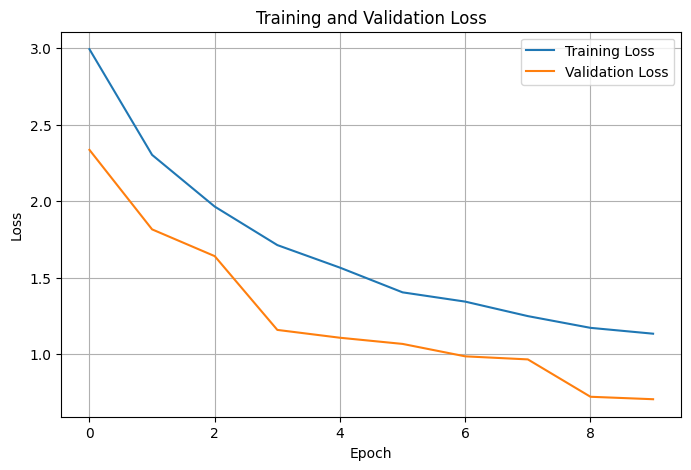

In [27]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")

plt.legend()
plt.grid(True)

plt.show()

In [28]:
test_loss, test_accuracy = model.evaluate(test_generator)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - accuracy: 0.7741 - loss: 0.7227
Test Loss: 0.7227166295051575
Test Accuracy: 0.7740963697433472


In [29]:
import numpy as np

predictions = model.predict(test_generator)

predicted_classes = np.argmax(
    predictions,
    axis=1
)

true_classes = test_generator.classes

class_names = list(
    test_generator.class_indices.keys()
)

print("Predictions completed!")
print("Number of predictions:", len(predicted_classes))

52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step
Predictions completed!
Number of predictions: 1660


In [30]:
from sklearn.metrics import classification_report

report = classification_report(
    true_classes,
    predicted_classes,
    target_names=class_names
)

print(report)

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       1.00      0.20      0.33        20
                                 Apple___Black_rot       0.58      0.55      0.56        20
                          Apple___Cedar_apple_rust       1.00      0.11      0.20         9
                                   Apple___healthy       0.72      0.66      0.69        50
                               Blueberry___healthy       0.62      1.00      0.76        45
          Cherry_(including_sour)___Powdery_mildew       0.75      0.66      0.70        32
                 Cherry_(including_sour)___healthy       0.75      0.56      0.64        27
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.62      0.50      0.55        16
                       Corn_(maize)___Common_rust_       0.92      0.97      0.95        37
               Corn_(maize)___Northern_Leaf_Blight       0.73      0.71      0.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


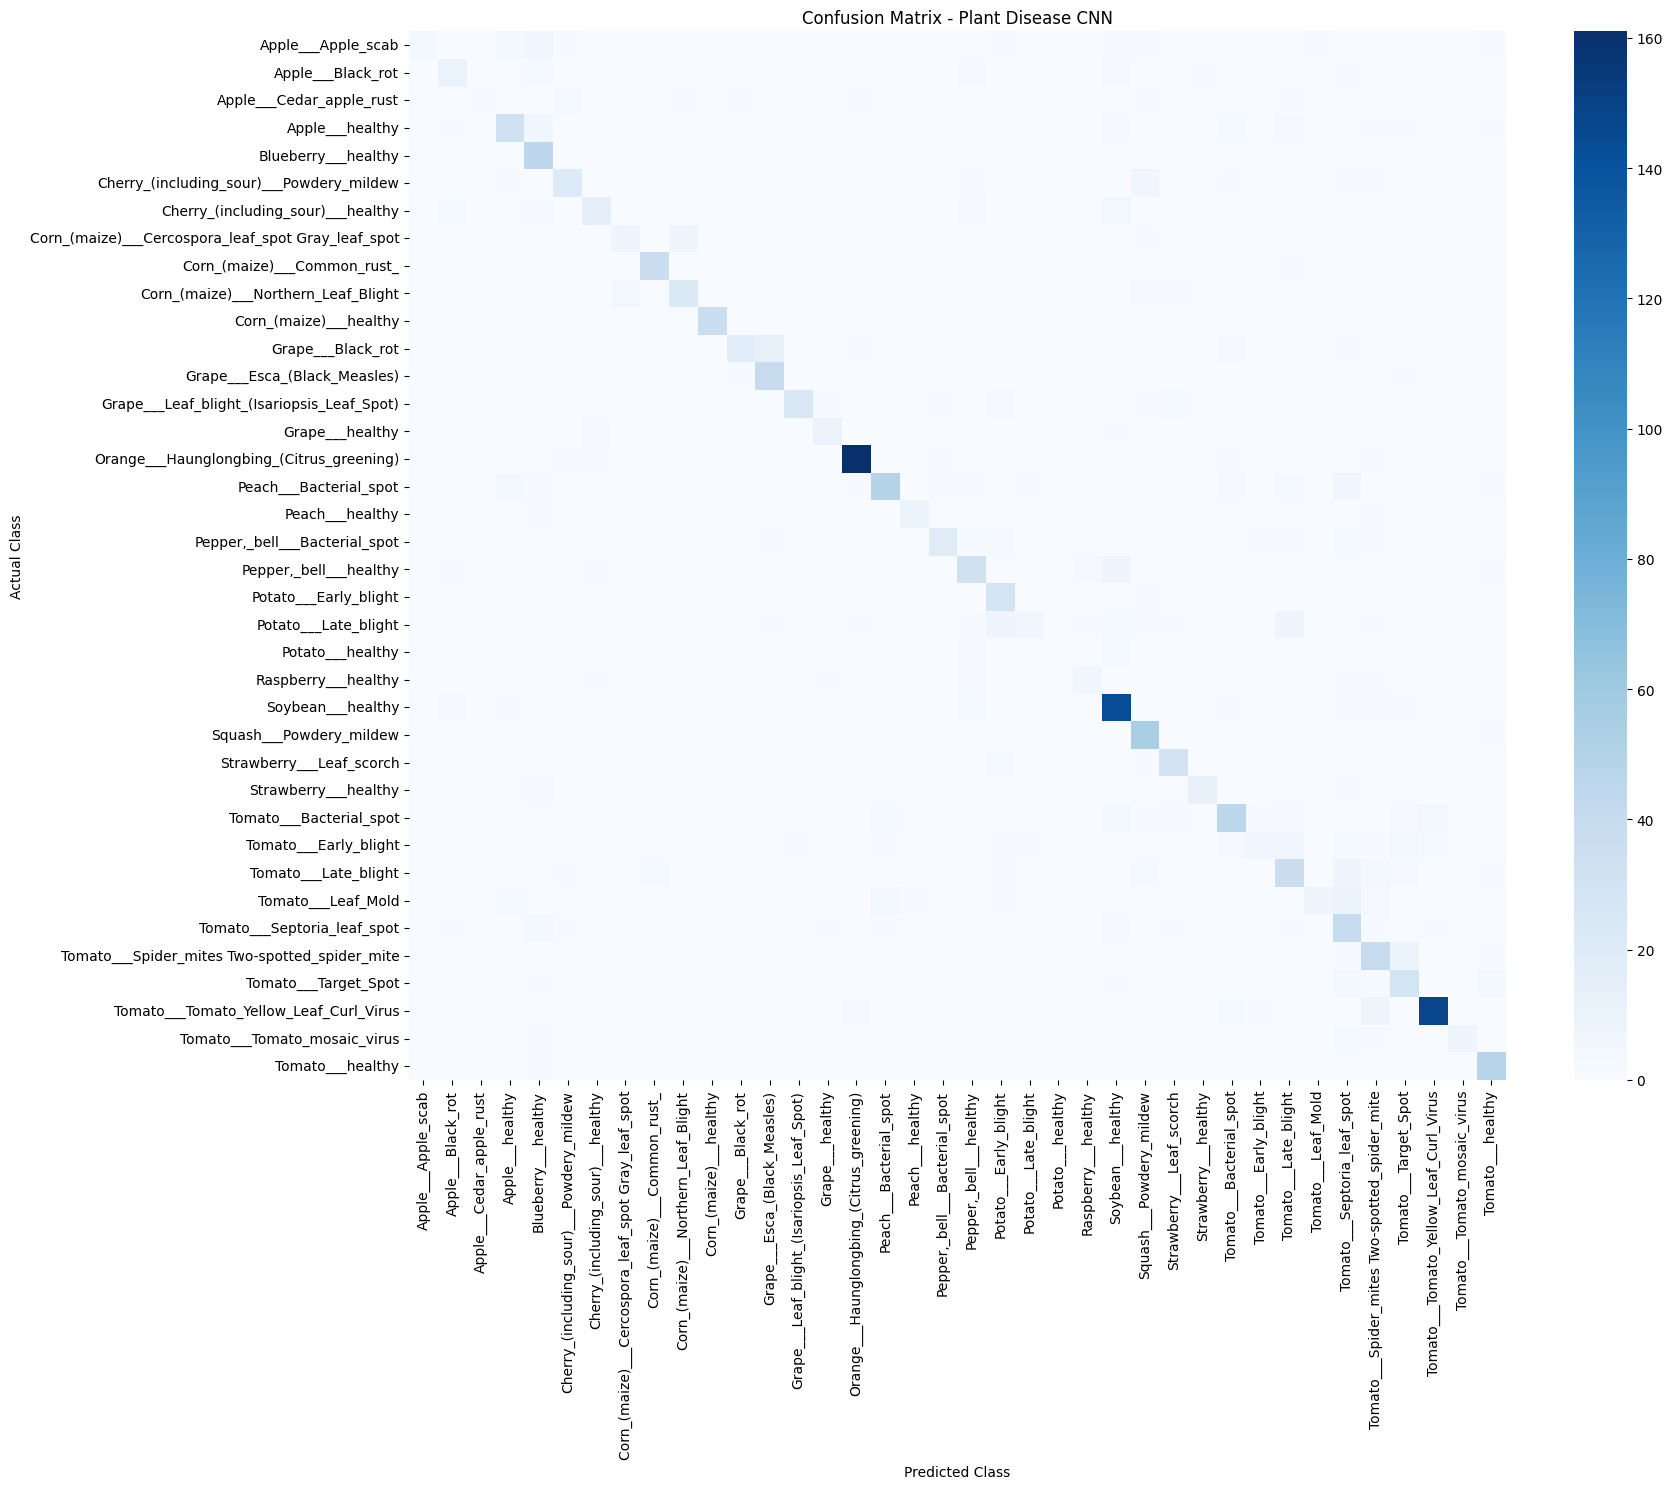

In [31]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(
    true_classes,
    predicted_classes
)

plt.figure(figsize=(18, 15))

sns.heatmap(
    cm,
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Confusion Matrix - Plant Disease CNN")

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [32]:
import os

os.makedirs("/content/models", exist_ok=True)

model.save("/content/models/plant_disease_cnn.keras")

print("Model saved successfully!")

Model saved successfully!


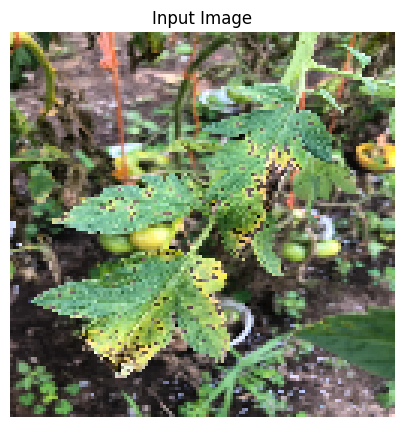

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 881ms/step
Predicted Class: Tomato___Septoria_leaf_spot
Confidence: 38.16%


In [35]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

# Path to your new image
img_path = "/tomato_leaf.webp"

# Load and resize image
img = image.load_img(
    img_path,
    target_size=(128, 128)
)

# Display image
plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.axis("off")
plt.title("Input Image")
plt.show()

# Convert image to array
img_array = image.img_to_array(img)

# Normalize pixel values
img_array = img_array / 255.0

# Add batch dimension
img_array = np.expand_dims(img_array, axis=0)

# Make prediction
prediction = model.predict(img_array)

# Get predicted class
predicted_index = np.argmax(prediction[0])

predicted_class = class_names[predicted_index]

# Get confidence
confidence = prediction[0][predicted_index] * 100

print("Predicted Class:", predicted_class)
print("Confidence: {:.2f}%".format(confidence))